# Entrega 1 — EDA y Baseline
## Sistema de Recomendación de Películas: MovieLens 100K

**Curso:** Aprendizaje de Máquina Aplicado — EAFIT  
**Profesor:** Marco Teran  
**Dataset:** MovieLens 100K — GroupLens Research  
**Fecha límite:** 23/04/2026  

---

### Pregunta central
> ¿Es posible predecir el rating (1–5) que un usuario le daría a una película que no ha visto?

In [7]:
import warnings

# Data manipulatio
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [8]:
# Path to raw data
DATA_PATH = '../data/raw/ml-100k/'

# Ratings
ratings = pd.read_csv(
    DATA_PATH + 'u.data',
    sep='\t',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)

# Users
users = pd.read_csv(
    DATA_PATH + 'u.user',
    sep='|',
    names=['user_id', 'age', 'gender', 'occupation', 'zip_code']
)

# Movies
movie_cols = [
    'item_id', 'title', 'release_date', 'video_release_date', 'imdb_url',
    'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

movies = pd.read_csv(
    DATA_PATH + 'u.item',
    sep='|',
    encoding='latin-1',
    names=movie_cols
)

print(f"Ratings:  {ratings.shape[0]:,} rows × {ratings.shape[1]} columns")
print(f"Users:    {users.shape[0]:,} rows × {users.shape[1]} columns")
print(f"Movies:   {movies.shape[0]:,} rows × {movies.shape[1]} columns")

Ratings:  100,000 rows × 4 columns
Users:    943 rows × 5 columns
Movies:   1,682 rows × 24 columns


In [9]:
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [10]:
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [11]:
movies.head()

,item_id,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [14]:
# --- Ratings ---
print("=" * 45)
print("RATINGS")
print("=" * 45)
print(ratings.isnull().sum())
print(f"\nDuplicates: {ratings.duplicated().sum()}")
print(f"Rating range: {ratings['rating'].min()} – {ratings['rating'].max()}")

# --- Users ---
print("\n" + "=" * 45)
print("USERS")
print("=" * 45)
print(users.isnull().sum())

# --- Movies ---
print("\n" + "=" * 45)
print("MOVIES")
print("=" * 45)
print(movies.isnull().sum())

RATINGS
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

Duplicates: 0
Rating range: 1 – 5

USERS
user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64

MOVIES
item_id                  0
title                    0
release_date             1
video_release_date    1682
imdb_url                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Children                 0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64


## Hallazgos de calidad de datos

- **Ratings**: sin nulos, sin duplicados, rango válido (1–5). ✓
- **Users**: sin nulos en ninguna columna. ✓
- **Movies**:
  - `video_release_date`: 1,682/1,682 nulos → se descarta completamente.
  - `imdb_url`: sin valor predictivo → se descarta.
  - `release_date`: 1 nulo → se conserva, se tratará al extraer el año.
  - Columnas de géneros: sin nulos, codificación binaria correcta. ✓

In [15]:
# Drop columns with no predictive value
movies.drop(columns=['video_release_date', 'imdb_url'], inplace=True)

print(f"Movies columns after cleaning: {movies.shape[1]}")
print(movies.columns.tolist())

Movies columns after cleaning: 22
['item_id', 'title', 'release_date', 'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [17]:
# Extract release year from release_date
movies['release_year'] = pd.to_datetime(
    movies['release_date'], errors='coerce'
).dt.year

# Check the result
print(movies[['title', 'release_date', 'release_year']].head(10))
print(f"\nNulls in release_year: {movies['release_year'].isnull().sum()}")
print(f"Year range: {movies['release_year'].min():.0f} – {movies['release_year'].max():.0f}")

                                               title release_date  \
0                                   Toy Story (1995)  01-Jan-1995   
1                                   GoldenEye (1995)  01-Jan-1995   
2                                  Four Rooms (1995)  01-Jan-1995   
3                                  Get Shorty (1995)  01-Jan-1995   
4                                     Copycat (1995)  01-Jan-1995   
5  Shanghai Triad (Yao a yao yao dao waipo qiao) ...  01-Jan-1995   
6                              Twelve Monkeys (1995)  01-Jan-1995   
7                                        Babe (1995)  01-Jan-1995   
8                            Dead Man Walking (1995)  01-Jan-1995   
9                                 Richard III (1995)  22-Jan-1996   

   release_year  
0        1995.0  
1        1995.0  
2        1995.0  
3        1995.0  
4        1995.0  
5        1995.0  
6        1995.0  
7        1995.0  
8        1995.0  
9        1996.0  

Nulls in release_year: 1
Year range: 1922

In [ ]:
# Fill the single null with the median year
median_year = movies['release_year'].median()
movies['release_year'] = movies['release_year'].fillna(median_year)

print(f"Null filled with median year: {median_year:.0f}")
print(f"Nulls remaining: {movies['release_year'].isnull().sum()}")

Null filled with median year: 1995
Nulls remaining: 0


## Análisis Exploratorio de Datos (EDA)

### 1. Distribución de ratings

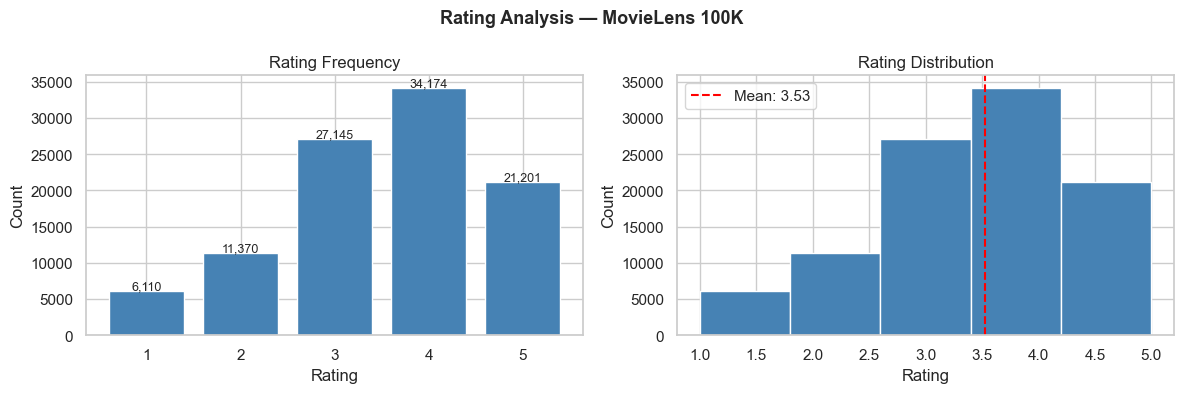

Global mean rating : 3.5299
Standard deviation : 1.1257
Median             : 4.0


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating counts
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Frequency')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Cumulative distribution
mean_rating = ratings['rating'].mean()
axes[1].hist(ratings['rating'], bins=5, color='steelblue', edgecolor='white')
axes[1].axvline(mean_rating, color='red', linestyle='--', label=f'Mean: {mean_rating:.2f}')
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Rating Analysis — MovieLens 100K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/01_rating_distribution.png', bbox_inches='tight')
plt.show()

print(f"Global mean rating : {mean_rating:.4f}")
print(f"Standard deviation : {ratings['rating'].std():.4f}")
print(f"Median             : {ratings['rating'].median():.1f}")

**Hallazgo:** Los ratings muestran sesgo de positividad — la media (~3.5) está por encima 
del punto medio de la escala (3.0). Ratings 3 y 4 concentran la mayoría de las interacciones. 
Esto implica que un baseline de media global ya captura parte del patrón.

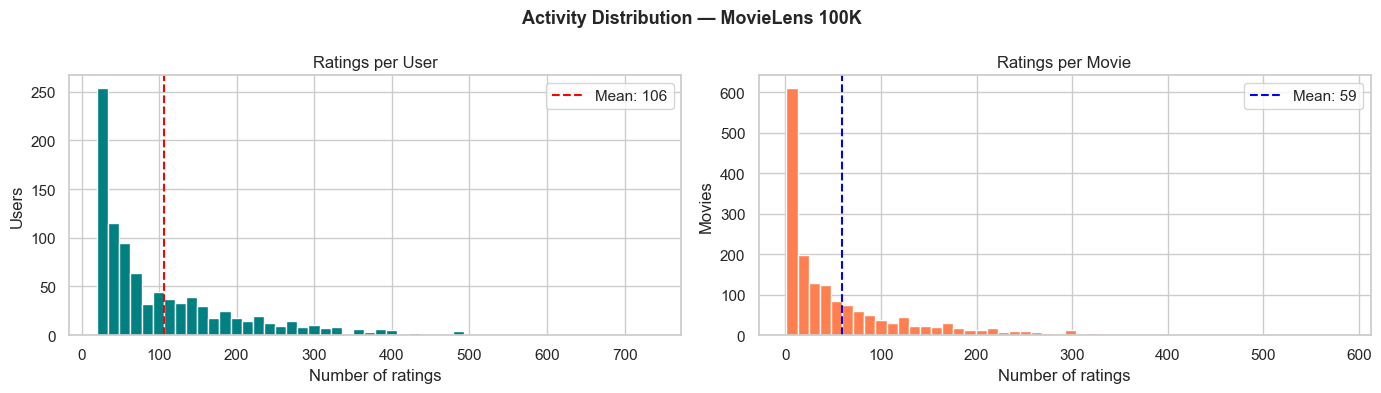

Unique users  : 943
Unique movies : 1,682
Total ratings : 100,000
Matrix size   : 943 × 1682 = 1,586,126 possible ratings
Sparsity      : 93.70%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ratings_per_user  = ratings.groupby('user_id')['rating'].count()
ratings_per_movie = ratings.groupby('item_id')['rating'].count()

# Ratings per user
axes[0].hist(ratings_per_user, bins=50, color='teal', edgecolor='white')
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Users')
axes[0].axvline(ratings_per_user.mean(), color='red', linestyle='--',
                label=f'Mean: {ratings_per_user.mean():.0f}')
axes[0].legend()

# Ratings per movie
axes[1].hist(ratings_per_movie, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Movies')
axes[1].axvline(ratings_per_movie.mean(), color='blue', linestyle='--',
                label=f'Mean: {ratings_per_movie.mean():.0f}')
axes[1].legend()

plt.suptitle('Activity Distribution — MovieLens 100K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/02_activity_distribution.png', bbox_inches='tight')
plt.show()

# Sparsity
n_users   = ratings['user_id'].nunique()
n_movies  = ratings['item_id'].nunique()
n_ratings = len(ratings)
sparsity  = 1 - (n_ratings / (n_users * n_movies))

print(f"Unique users  : {n_users:,}")
print(f"Unique movies : {n_movies:,}")
print(f"Total ratings : {n_ratings:,}")
print(f"Matrix size   : {n_users} × {n_movies} = {n_users * n_movies:,} possible ratings")
print(f"Sparsity      : {sparsity:.2%}")

**Hallazgo:** La matriz usuario–película tiene una sparsity del 93.70% — solo 100,000 de 
1,586,126 combinaciones posibles tienen rating. Ambas distribuciones muestran cola larga: 
pocos usuarios y pocas películas concentran la mayoría de interacciones. Esto introduce 
el problema de **cold start**: el modelo tendrá menor precisión para usuarios con pocas 
calificaciones y películas poco vistas.

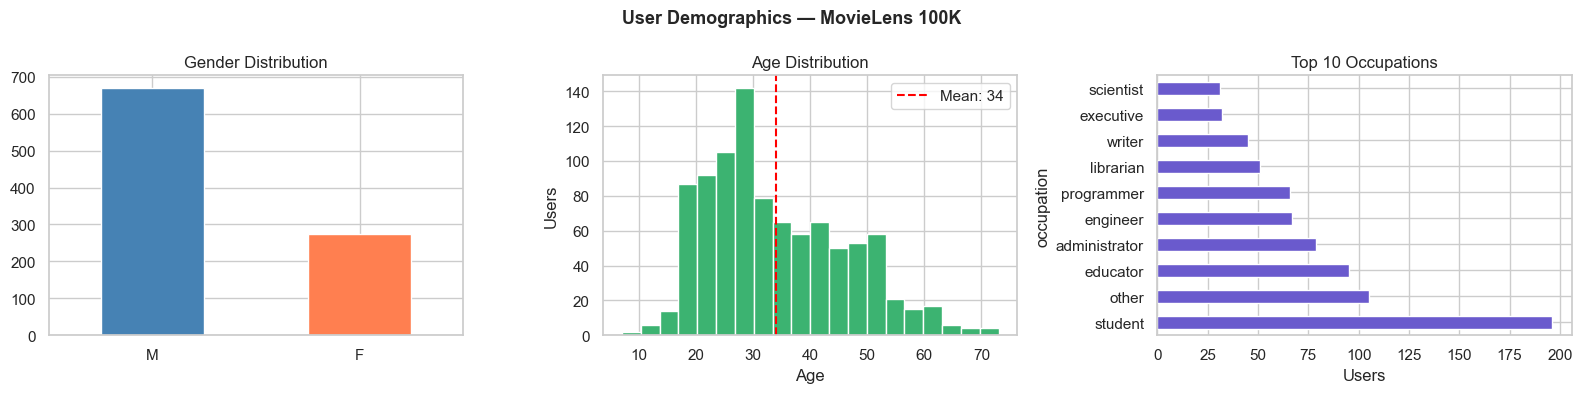

Gender breakdown:
gender
M    670
F    273
Name: count, dtype: int64

Age — mean: 34.1, median: 31


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Gender
users['gender'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

# Age
axes[1].hist(users['age'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Users')
axes[1].axvline(users['age'].mean(), color='red', linestyle='--',
                label=f'Mean: {users["age"].mean():.0f}')
axes[1].legend()

# Top 10 occupations
users['occupation'].value_counts().head(10).plot(
    kind='barh', ax=axes[2], color='slateblue', edgecolor='white')
axes[2].set_title('Top 10 Occupations')
axes[2].set_xlabel('Users')

plt.suptitle('User Demographics — MovieLens 100K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_user_demographics.png', bbox_inches='tight')
plt.show()

print(f"Gender breakdown:\n{users['gender'].value_counts()}")
print(f"\nAge — mean: {users['age'].mean():.1f}, median: {users['age'].median():.0f}")

In [26]:
print(f"Age stats:")
print(f"  Min    : {users['age'].min()}")
print(f"  Max    : {users['age'].max()}")
print(f"  Mean   : {users['age'].mean():.1f}")
print(f"  Median : {users['age'].median():.0f}")
print(f"\nUsers older than 60: {(users['age'] > 60).sum()}")
print(f"Users younger than 18: {(users['age'] < 18).sum()}")

Age stats:
  Min    : 7
  Max    : 73
  Mean   : 34.1
  Median : 31

Users older than 60: 22
Users younger than 18: 36


**Hallazgo:** El perfil demográfico muestra sesgo significativo — aproximadamente 3 de cada 4 
usuarios son hombres, la ocupación más frecuente es estudiante, y aunque el rango de edad 
es amplio (7–73 años), la mediana es 31. La media (34.1) está jalada por usuarios mayores. 
El modelo aprenderá principalmente de las preferencias de hombres jóvenes, lo que limita 
su generalización a otros perfiles demográficos.